In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

Graph successfully generated and saved as 'predicted_vs_actual_parity.png'.

--- MLR Parameter Estimation Results ---
                    Model           k          KA          KE          KW  R2_linear  RMSE_linear
      M1: Single-Site (A) -3.9101e-06 -7.3708e-01  0.0000e+00  0.0000e+00 9.4642e-01   1.1773e+05
        M2: Dual-Site (A)  6.5005e-05  9.6236e-01  0.0000e+00  0.0000e+00 9.7920e-01   4.5658e+01
   M3: Single-Site (A, E) -2.9285e-06 -5.8025e-01 -4.5597e-02  0.0000e+00 9.5751e-01   1.0484e+05
     M4: Dual-Site (A, E)  1.3258e-04  1.4225e+00  7.7768e-02  0.0000e+00 9.8459e-01   3.9304e+01
   M5: Single-Site (A, W) -3.3937e-06 -6.5068e-01  0.0000e+00 -2.6076e-02 9.4913e-01   1.1471e+05
     M6: Dual-Site (A, W)  2.2126e-04  1.8454e+00  0.0000e+00  1.6683e-01 9.9414e-01   2.4245e+01
M7: Single-Site (A, E, W) -2.6071e-06 -5.2573e-01 -4.1134e-02 -2.1085e-02 9.6052e-01   1.0106e+05
  M8: Dual-Site (A, E, W)  1.3207e-03  4.6698e+00  2.5611e-01  4.1416e-01 1.0000e+00   6.1380e-01


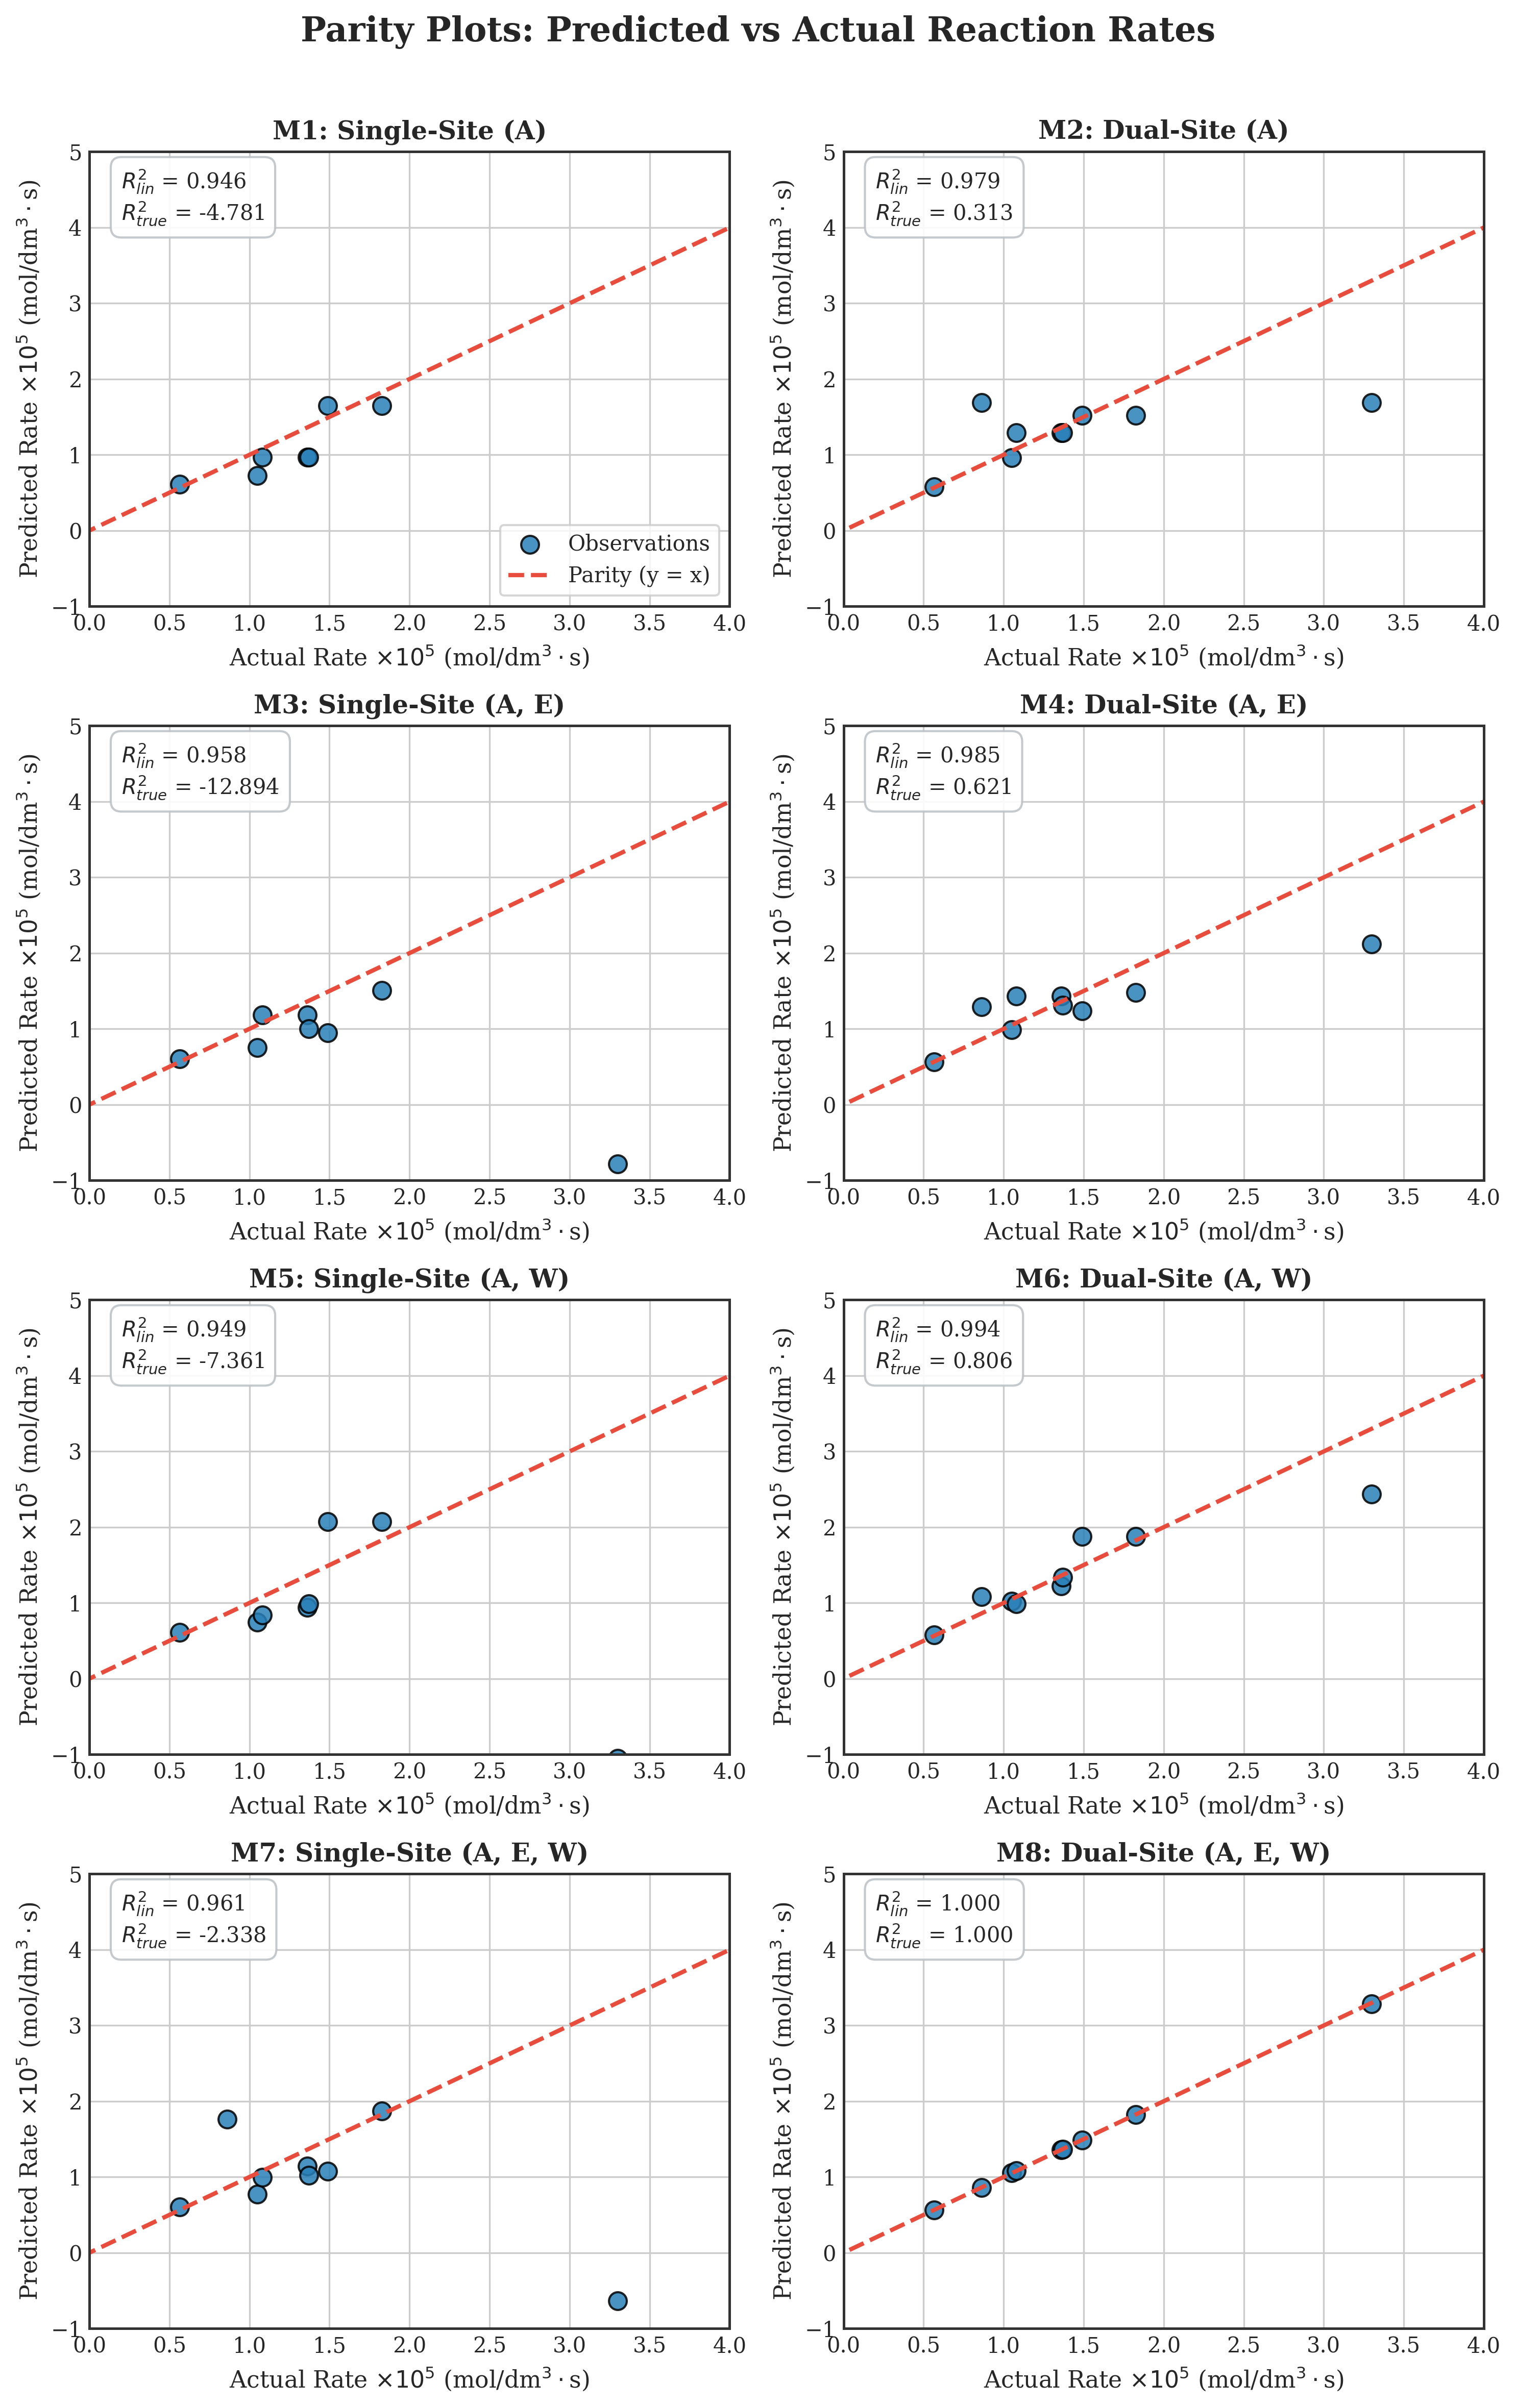

In [3]:
def main():
    # ---------------------------------------------------------
    # 1. Publication-Ready Plot Settings
    # ---------------------------------------------------------
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        'font.family': 'serif',
        'axes.labelsize': 11,
        'axes.titlesize': 12,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 10,
        'figure.dpi': 300,
        'axes.edgecolor': '#333333',
        'axes.linewidth': 1.2
    })

    # ---------------------------------------------------------
    # 2. Ground Truth Data Setup
    # ---------------------------------------------------------
    # Extracted from the differential reactor data
    rate_full = np.array([3.3, 1.05, 0.565, 1.826, 1.49, 1.36, 1.08, 0.862, 0, 1.37]) * 1e-5
    PA_full = np.array([1, 5, 10, 2, 2, 3, 3, 1, 0, 3])
    PE_full = np.array([1, 1, 1, 5, 10, 0, 0, 10, 5, 3])
    PW_full = np.array([1, 1, 1, 1, 1, 5, 10, 10, 8, 3])

    # Filter out Run 9 (index 8) to avoid 0 divisor/logarithm issues
    idx = [0, 1, 2, 3, 4, 5, 6, 7, 9]
    rate = rate_full[idx]
    PA = PA_full[idx]
    PE = PE_full[idx]
    PW = PW_full[idx]

    # Transformed targets for regression
    Y_s = PA / rate
    Y_d = np.sqrt(PA / rate)

    # Independent variables arrays
    X1 = PA.reshape(-1, 1) # Reshape for sklearn
    X2 = np.column_stack((PA, PE))
    X3 = np.column_stack((PA, PW))
    X4 = np.column_stack((PA, PE, PW))

    # Model configuration tuple: (X_data, Y_data, is_dual, title)
    model_configs = [
        (X1, Y_s, False, 'M1: Single-Site (A)'),
        (X1, Y_d, True,  'M2: Dual-Site (A)'),
        (X2, Y_s, False, 'M3: Single-Site (A, E)'),
        (X2, Y_d, True,  'M4: Dual-Site (A, E)'),
        (X3, Y_s, False, 'M5: Single-Site (A, W)'),
        (X3, Y_d, True,  'M6: Dual-Site (A, W)'),
        (X4, Y_s, False, 'M7: Single-Site (A, E, W)'),
        (X4, Y_d, True,  'M8: Dual-Site (A, E, W)')
    ]

    # ---------------------------------------------------------
    # 3. Model Fitting & Plotting Iteration
    # ---------------------------------------------------------
    results = []
    fig, axes = plt.subplots(4, 2, figsize=(10, 16))
    axes = axes.flatten()
    fig.suptitle('Parity Plots: Predicted vs Actual Reaction Rates', 
                 fontsize=16, fontweight='bold', y=0.98)

    for i, (X, y, is_dual, name) in enumerate(model_configs):
        # Fit with sklearn
        model = LinearRegression(fit_intercept=True).fit(X, y)
        
        # Combine intercept and coefficients to match previous statsmodels format: [intercept, coef1, coef2...]
        b = np.concatenate([[model.intercept_], model.coef_])
        
        # Calculate intrinsic and equilibrium constants
        if is_dual:
            k = (1 / b[0])**2
            sf = np.sqrt(k)
        else:
            k = 1 / b[0]
            sf = k
            
        KA = b[1] * sf
        KE = 0; KW = 0
        
        if i in [2, 3]:   # M3, M4
            KE = b[2] * sf
        elif i in [4, 5]: # M5, M6
            KW = b[2] * sf
        elif i in [6, 7]: # M7, M8
            KE = b[2] * sf
            KW = b[3] * sf
            
        # Get MLR predictions and project back to original rate scale
        y_pred_linear = model.predict(X)
        if is_dual:
            rate_pred = PA / (y_pred_linear**2)
        else:
            rate_pred = PA / y_pred_linear
            
        # Statistics
        lin_R2 = r2_score(y, y_pred_linear)
        lin_RMSE = np.sqrt(mean_squared_error(y, y_pred_linear))
        
        # True Non-Linear R2 (calculated on actual rate)
        ss_res = np.sum((rate - rate_pred)**2)
        ss_tot = np.sum((rate - np.mean(rate))**2)
        true_r2 = 1 - (ss_res / ss_tot)

        # Scale arrays for visual clarity (* 1e5)
        act_scaled = rate * 1e5
        pred_scaled = rate_pred * 1e5
        
        # --- Plotting logic for this subplot ---
        ax = axes[i]
        
        # Plot data points
        ax.scatter(act_scaled, pred_scaled, c='#2980b9', alpha=0.85, 
                   edgecolor='black', s=70, label='Observations')
        
        # Plot Parity Line (y = x)
        line_vals = np.linspace(-2, 6, 100)
        ax.plot(line_vals, line_vals, color='#e74c3c', linestyle='--', 
                linewidth=2, label='Parity (y = x)')
        
        # Standardize axis limits so all plots are directly comparable
        # This forces badly broken single-site models off-chart visually
        ax.set_xlim(0, 4)
        ax.set_ylim(-1, 5)
        
        ax.set_title(name, fontweight='bold', fontsize=12)
        ax.set_xlabel(r'Actual Rate $\times 10^5$ (mol/dm$^3\cdot$s)')
        ax.set_ylabel(r'Predicted Rate $\times 10^5$ (mol/dm$^3\cdot$s)')
        
        if i == 0: # Only put legend in first plot to save space
            ax.legend(loc='lower right', frameon=True)
            
        # Store results for table
        results.append([name, k, KA, KE, KW, lin_R2, lin_RMSE])

    # Finalize plot formatting
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    # Save the figure as a high-res PNG for the publication
    plt.savefig('predicted_vs_actual_parity.png', dpi=300, bbox_inches='tight')
    print("Graph successfully generated and saved as 'predicted_vs_actual_parity.png'.\n")
    # plt.show() # Uncomment to view in interactive environments

    # ---------------------------------------------------------
    # 4. Results Consolidation
    # ---------------------------------------------------------
    columns = ['Model', 'k', 'KA', 'KE', 'KW', 'R2_linear', 'RMSE_linear']
    df_results = pd.DataFrame(results, columns=columns)
    
    # Format floating point numbers for clean console output
    pd.options.display.float_format = '{:.4e}'.format
    
    print("--- MLR Parameter Estimation Results ---")
    print(df_results.to_string(index=False))

if __name__ == "__main__":
    main()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


Graph successfully generated and saved as 'predicted_vs_actual_parity.png'.

--- MLR Parameter Estimation Results ---
                    Model           k       KA(a)       KE(b)       KW(g)  R2_linear     True_R2   RMSE_lin
      M1: Single-Site (A) -3.9101e-06 -7.3708e-01  0.0000e+00  0.0000e+00 9.4642e-01 -4.7811e+00 1.1773e+05
        M2: Dual-Site (A)  6.5005e-05  9.6236e-01  0.0000e+00  0.0000e+00 9.7920e-01  3.1275e-01 4.5658e+01
   M3: Single-Site (A, E) -2.9285e-06 -5.8025e-01 -4.5597e-02  0.0000e+00 9.5751e-01 -1.2894e+01 1.0484e+05
     M4: Dual-Site (A, E)  1.3258e-04  1.4225e+00  7.7768e-02  0.0000e+00 9.8459e-01  6.2088e-01 3.9304e+01
   M5: Single-Site (A, W) -3.3937e-06 -6.5068e-01  0.0000e+00 -2.6076e-02 9.4913e-01 -7.3607e+00 1.1471e+05
     M6: Dual-Site (A, W)  2.2126e-04  1.8454e+00  0.0000e+00  1.6683e-01 9.9414e-01  8.0556e-01 2.4245e+01
M7: Single-Site (A, E, W) -2.6071e-06 -5.2573e-01 -4.1134e-02 -2.1085e-02 9.6052e-01 -2.3381e+00 1.0106e+05
  M8: Dual-Site (A

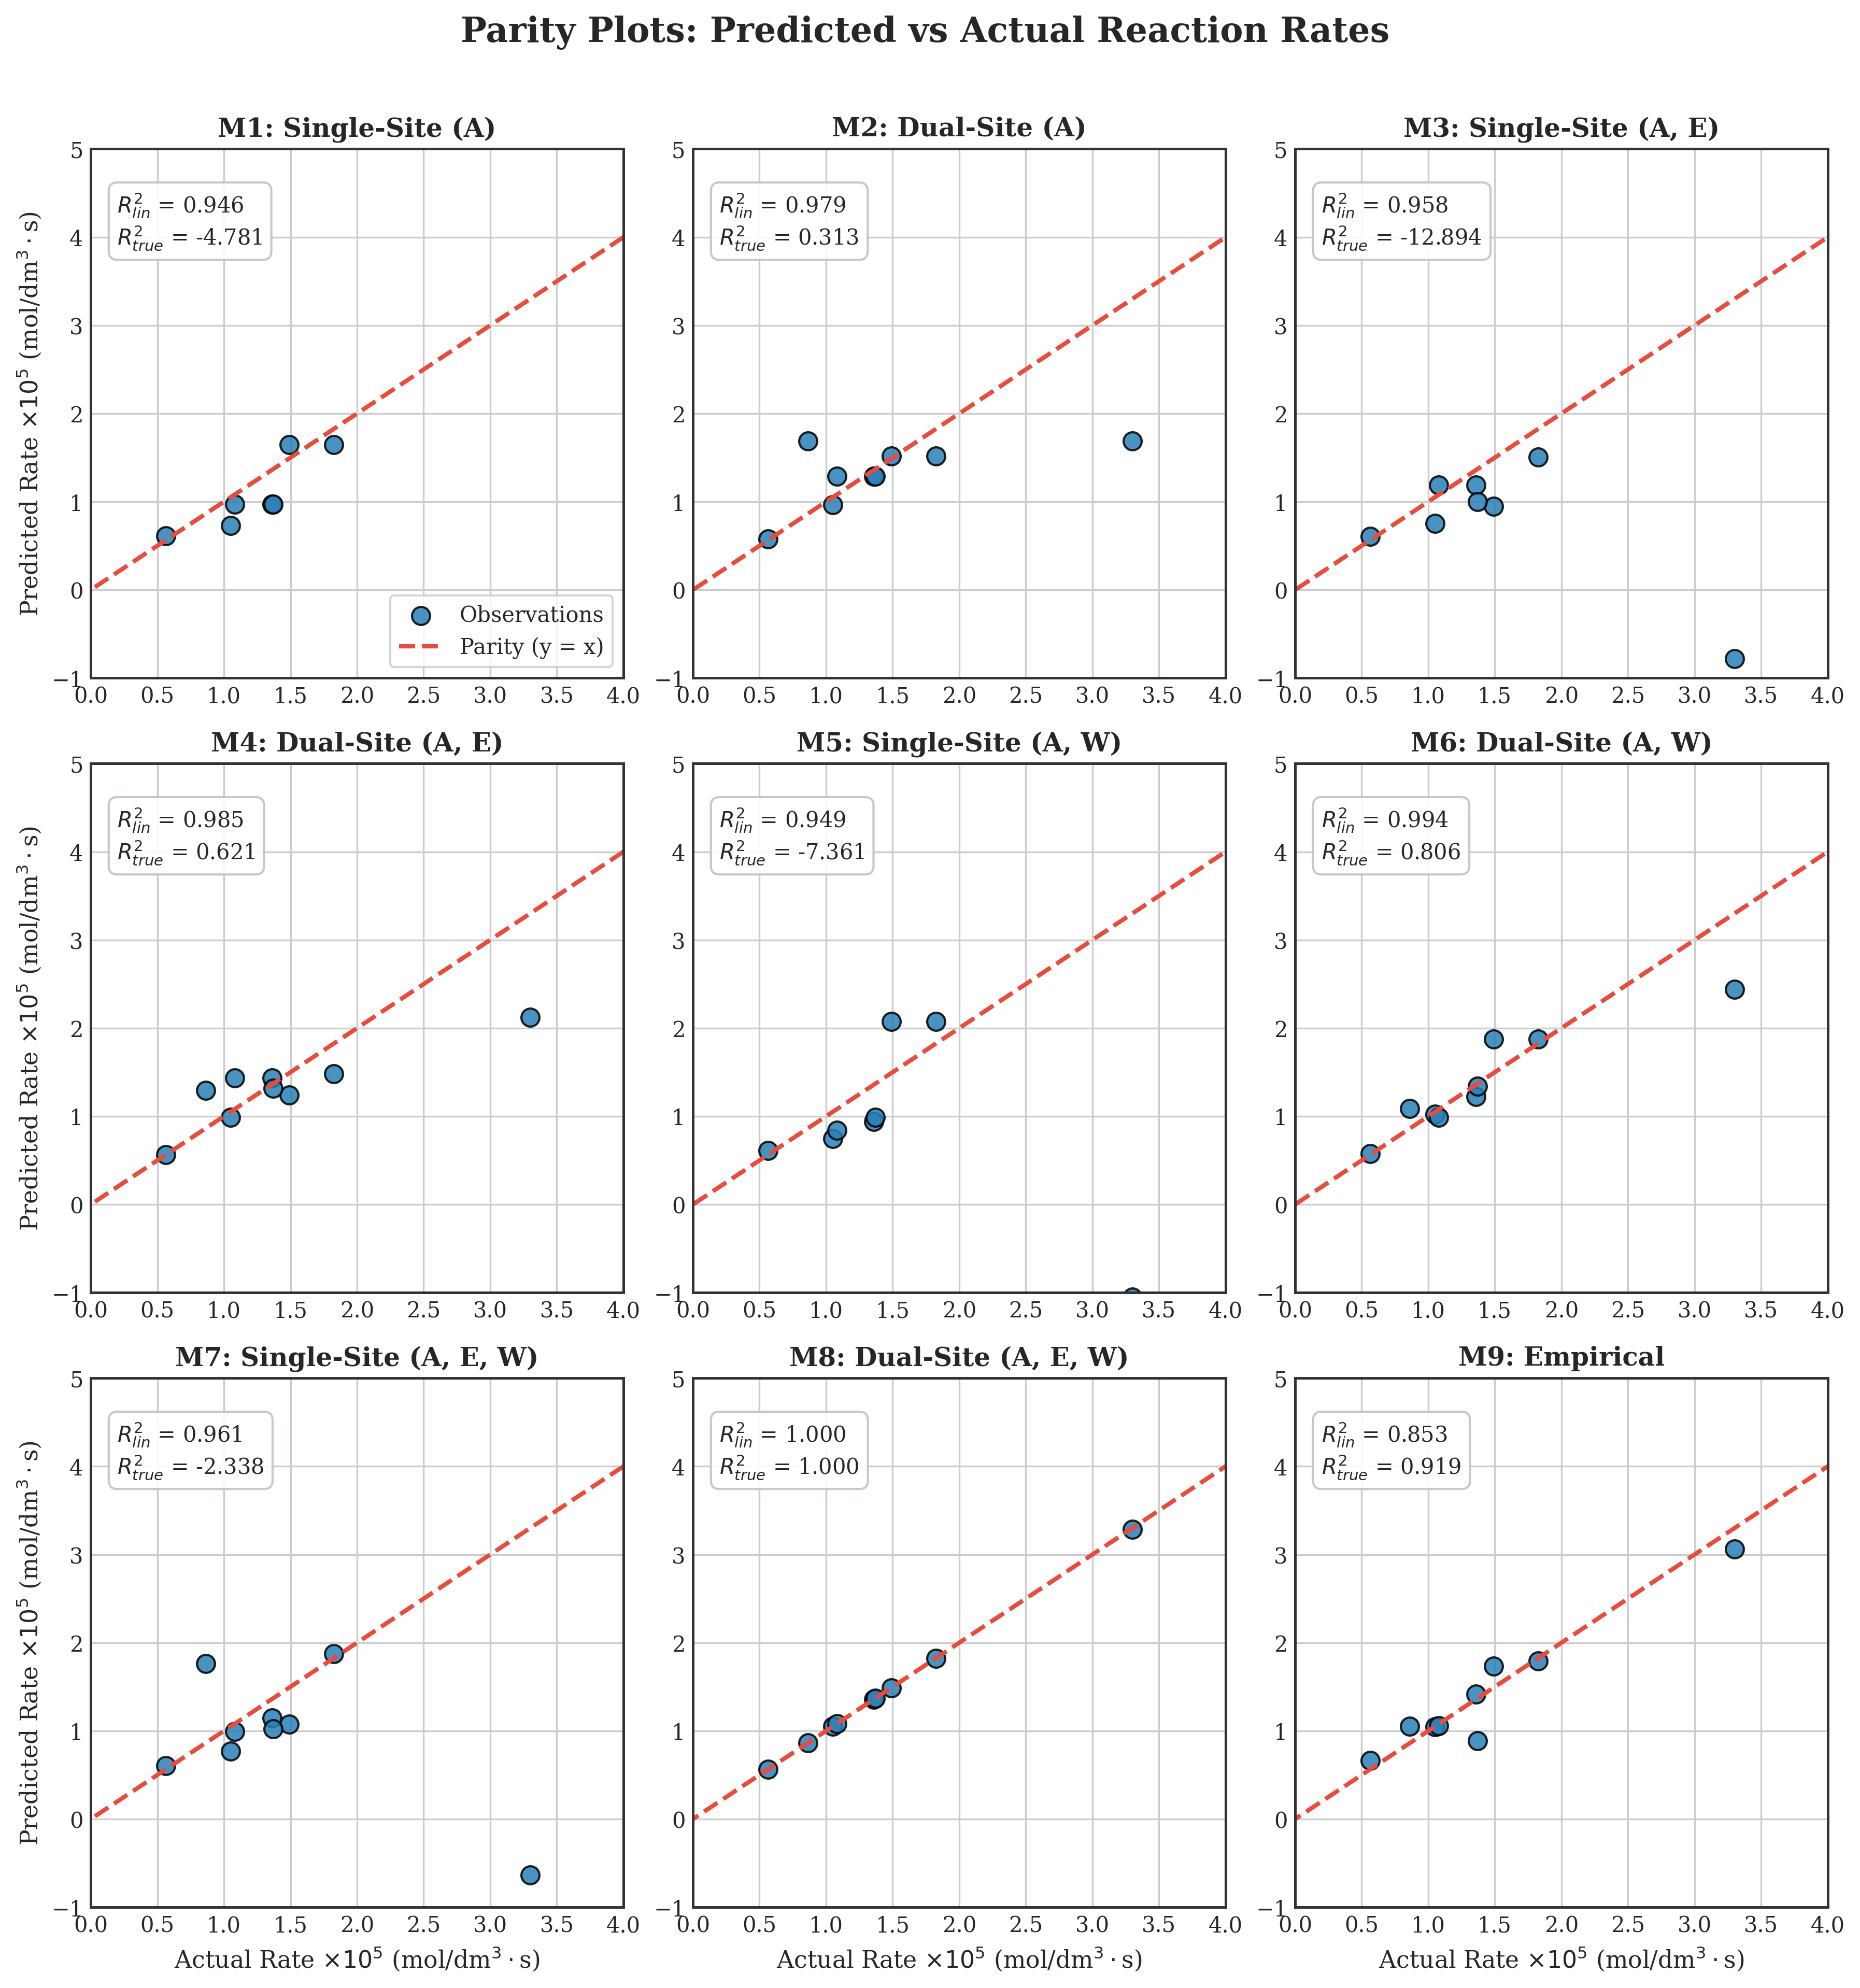

In [4]:

def main():
    # ---------------------------------------------------------
    # 1. Publication-Ready Plot Settings
    # ---------------------------------------------------------
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        'font.family': 'serif',
        'axes.labelsize': 11,
        'axes.titlesize': 12,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 10,
        'figure.dpi': 300,
        'axes.edgecolor': '#333333',
        'axes.linewidth': 1.2
    })

    # ---------------------------------------------------------
    # 2. Ground Truth Data Setup
    # ---------------------------------------------------------
    # Extracted from the differential reactor data
    rate_full = np.array([3.3, 1.05, 0.565, 1.826, 1.49, 1.36, 1.08, 0.862, 0, 1.37]) * 1e-5
    PA_full = np.array([1, 5, 10, 2, 2, 3, 3, 1, 0, 3])
    PE_full = np.array([1, 1, 1, 5, 10, 0, 0, 10, 5, 3])
    PW_full = np.array([1, 1, 1, 1, 1, 5, 10, 10, 8, 3])

    # Filter out Run 9 (index 8) to avoid 0 divisor/logarithm issues
    idx = [0, 1, 2, 3, 4, 5, 6, 7, 9]
    rate = rate_full[idx]
    PA = PA_full[idx]
    PE = PE_full[idx]
    PW = PW_full[idx]

    # Transformed targets for regression
    Y_s = PA / rate
    Y_d = np.sqrt(PA / rate)
    Y_emp = np.log(rate)

    # Independent variables arrays
    X1 = PA.reshape(-1, 1) # Reshape for sklearn
    X2 = np.column_stack((PA, PE))
    X3 = np.column_stack((PA, PW))
    X4 = np.column_stack((PA, PE, PW))
    X_emp = np.column_stack((np.log(PA), np.log(PE + 1e-6), np.log(PW + 1e-6)))

    # Model configuration tuple: (X_data, Y_data, is_dual, is_empirical, title)
    model_configs = [
        (X1, Y_s, False, False, 'M1: Single-Site (A)'),
        (X1, Y_d, True,  False, 'M2: Dual-Site (A)'),
        (X2, Y_s, False, False, 'M3: Single-Site (A, E)'),
        (X2, Y_d, True,  False, 'M4: Dual-Site (A, E)'),
        (X3, Y_s, False, False, 'M5: Single-Site (A, W)'),
        (X3, Y_d, True,  False, 'M6: Dual-Site (A, W)'),
        (X4, Y_s, False, False, 'M7: Single-Site (A, E, W)'),
        (X4, Y_d, True,  False, 'M8: Dual-Site (A, E, W)'),
        (X_emp, Y_emp, False, True, 'M9: Empirical')
    ]

    # ---------------------------------------------------------
    # 3. Model Fitting & Plotting Iteration
    # ---------------------------------------------------------
    results = []
    fig, axes = plt.subplots(3, 3, figsize=(12, 13)) # 3x3 grid for 9 models
    axes = axes.flatten()
    fig.suptitle('Parity Plots: Predicted vs Actual Reaction Rates', 
                 fontsize=16, fontweight='bold', y=0.98)

    for i, (X, y, is_dual, is_emp, name) in enumerate(model_configs):
        # Fit with sklearn
        model = LinearRegression(fit_intercept=True).fit(X, y)
        
        # Combine intercept and coefficients to match previous format: [intercept, coef1, coef2...]
        b = np.concatenate([[model.intercept_], model.coef_])
        
        # Calculate intrinsic and equilibrium constants
        if is_emp:
            k = np.exp(b[0])
            KA = b[1] # alpha
            KE = b[2] # beta
            KW = b[3] # gamma
        else:
            if is_dual:
                k = (1 / b[0])**2
                sf = np.sqrt(k)
            else:
                k = 1 / b[0]
                sf = k
                
            KA = b[1] * sf
            KE = 0; KW = 0
            
            if i in [2, 3]:   # M3, M4
                KE = b[2] * sf
            elif i in [4, 5]: # M5, M6
                KW = b[2] * sf
            elif i in [6, 7]: # M7, M8
                KE = b[2] * sf
                KW = b[3] * sf
                
        # Get MLR predictions and project back to original rate scale
        y_pred_linear = model.predict(X)
        
        if is_emp:
            rate_pred = np.exp(y_pred_linear)
        elif is_dual:
            rate_pred = PA / (y_pred_linear**2)
        else:
            rate_pred = PA / y_pred_linear
            
        # Statistics
        lin_R2 = r2_score(y, y_pred_linear)
        lin_RMSE = np.sqrt(mean_squared_error(y, y_pred_linear))
        
        # True Non-Linear R2 (calculated on actual rate)
        ss_res = np.sum((rate - rate_pred)**2)
        ss_tot = np.sum((rate - np.mean(rate))**2)
        true_r2 = 1 - (ss_res / ss_tot)

        # Scale arrays for visual clarity (* 1e5)
        act_scaled = rate * 1e5
        pred_scaled = rate_pred * 1e5
        
        # --- Plotting logic for this subplot ---
        ax = axes[i]
        
        # Plot data points
        ax.scatter(act_scaled, pred_scaled, c='#2980b9', alpha=0.85, 
                   edgecolor='black', s=70, label='Observations')
        
        # Plot Parity Line (y = x)
        line_vals = np.linspace(-2, 6, 100)
        ax.plot(line_vals, line_vals, color='#e74c3c', linestyle='--', 
                linewidth=2, label='Parity (y = x)')
        
        # Standardize axis limits so all plots are directly comparable
        ax.set_xlim(0, 4)
        ax.set_ylim(-1, 5)
        
        ax.set_title(name, fontweight='bold', fontsize=12)
        
        if i % 3 == 0:
            ax.set_ylabel(r'Predicted Rate $\times 10^5$ (mol/dm$^3\cdot$s)')
        if i >= 6:
            ax.set_xlabel(r'Actual Rate $\times 10^5$ (mol/dm$^3\cdot$s)')
        
        # Information Text Box
        text_str = f'$R^2_{{lin}}$ = {lin_R2:.3f}\n$R^2_{{true}}$ = {true_r2:.3f}'
        ax.text(0.05, 0.82, text_str, transform=ax.transAxes, fontsize=10,
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='#bdc3c7', boxstyle='round,pad=0.4'))
        
        if i == 0: # Only put legend in first plot to save space
            ax.legend(loc='lower right', frameon=True)
            
        # Store results for table
        results.append([name, k, KA, KE, KW, lin_R2, true_r2, lin_RMSE])

    # Finalize plot formatting
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    # Save the figure as a high-res PNG for the publication
    plt.savefig('predicted_vs_actual_parity.png', dpi=300, bbox_inches='tight')
    print("Graph successfully generated and saved as 'predicted_vs_actual_parity.png'.\n")
    # plt.show() # Uncomment to view in interactive environments

    # ---------------------------------------------------------
    # 4. Results Consolidation
    # ---------------------------------------------------------
    columns = ['Model', 'k', 'KA(a)', 'KE(b)', 'KW(g)', 'R2_linear', 'True_R2', 'RMSE_lin']
    df_results = pd.DataFrame(results, columns=columns)
    
    # Format floating point numbers for clean console output
    pd.options.display.float_format = '{:.4e}'.format
    
    print("--- MLR Parameter Estimation Results ---")
    print(df_results.to_string(index=False))

if __name__ == "__main__":
    main()